# Activation Functions

* Kushal Kharel


In the world of Neural Networks, activation functions are the gatekeepers. Without them, a neural network is just a giant stack of linear algebra, essentially glorified version of linear regression model that cannot handle the complexity of the real world.

A neural network calculates a weighted sum of inputs

$$
z = \sum w_ix_i + b
$$

If we do not apply an activation function, the output remains linear. Since the composition of linear function is always linear, a 100-layer network would have the same representational power as a single-layer model.

Activation functions introduce non-linearity which allows the network to learn "curvy" decision boundaries and complex patterns like faces, speech and sentiment.

We will discuss several activation functions in this article:
- The Heaviside Step Function
- Sigmoid
- Tanh
- ReLU
- Leaky ReLU
- Parametric ReLU
- ELU
- SELU
- Swish
- GELU
- SwiGLU
- Softmax



## 1. The Heaviside Step Function

The Step Function (or Binary Step) is the mathematical equivalent of a physical toggle switch. In early neural network theory (specially the McCulloch-Pitts neuron), a neuron either fires, in which case it is 1, or it doesn't, in which case it is zero.

The standard unit step function, denoted as $f(x)$ is defined as:

$$f(x) =
\begin{cases}
0 & \text{if } x < 0 \\
1 & \text{if } x \geq 0
\end{cases}$$

The advantage of using such as function is that it is computationally trivial and also it provides a definitive binary output, which is ideal for simple logic gates (AND, OR, NOT).




In modern deep learning, the step function is almost never used for hidden layers because of two mathematical flaws. The first is that the derivative of a step function is zero everywhere (except at $x = 0$, where it is undefined). Since backpropagation relies on the gradient to update weights, a zero gradient means the model cannot learn. If we change the weights slightly, the output does not change at all until it suddenly jumps. The second is that it cannot represent uncertainty. A value of 0.001 and 1000 both result in an output of 1.

In the 1980's the field shifted toward the Sigmoid (Logistic) function. The move from step to sigmoid was driven by the need for differentiability where we can calcualte gradients everywhere.

Researchers needed a function that looked like a step function but smooth which will allow for gradient descent where we can make tiny adjustments to weights and see a corresponding tiny change in the output.


## 2. Sigmoid Function

The sigmoid function $\sigma(x)$ is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-z}}
$$

Unlike the step function, sigmoid has a beautiful, bell-shaped derivative

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$
which allows the chain rule to work during backpropagation. The output is strictly between 0 and 1 which allows us to interpret the output as a probability. It also prevented exploding outputs by squashing any input no matter how large it is into a narrow range.

While sigmoid solved the "zero gradient" problem of the step function, it introduces a new problem, that is, *Saturation*. As $x$ becomes very large or very small, the curve becomes very flat. The gradient becomes so small (near zero) that the network stops learning. This phenomenon is called the *Vanishing Gradient Problem*.



In [ ]:
import numpy as np
import torch
import torch.nn as nn
from scipy.special import erf
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# Define Functions

def step_function(x):
  return np.where(x>=0,1,0)

def sigmoid(x):
  return 1/(1 + np.exp(-x))

# Define their derivatives (Gradients)

def step_gradient(x):
  return np.zeros_like(x)

def sigmoid_gradient(x):
  s = sigmoid(x)
  return s * (1 - s)

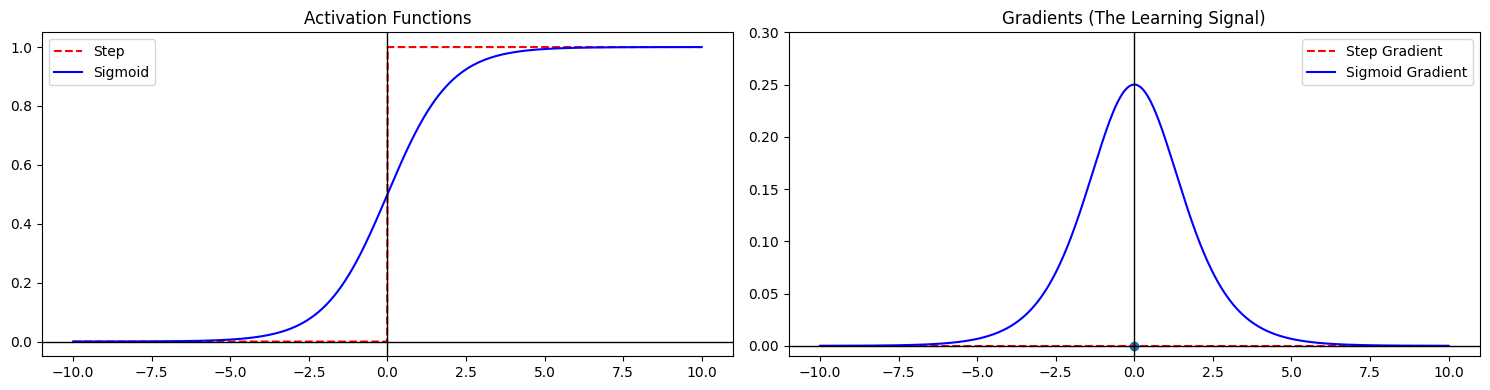

In [ ]:
x = np.linspace(-10,10, 1000)

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(x, step_function(x), label="Step", color="red", linestyle="--")
plt.plot(x, sigmoid(x), label="Sigmoid", color="blue")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Activation Functions")
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, step_gradient(x), label="Step Gradient", color="red", linestyle="--")
plt.scatter([0], [0])
plt.plot(x, sigmoid_gradient(x), label="Sigmoid Gradient", color="blue")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.ylim(-0.01, 0.3)
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Looking at the second plot we can notice that the step gradient is a flat line at zero and at zero it is undefined. When a neural network calculates how to change a weight $w$, it uses the updated rule:

$$
\Delta w = -\eta \frac{\partial Loss}{\partial w}
$$

Since the gradient of the step function is 0, the update $\Delta w$ becomes zero. It cannot learn through trial and error because it cannot see which direction to move.

Now, let's look at the blue line in the gradient plot. Notice that the maximum value for sigmoid is only $0.25$ at $x = 0$. As the input $x$ moves toward $+10$ or $-10$, the gradient becomes infinitesimally small. We know that in a deep network with 10 layers, the gradient is multiplied by itself at each layer. If each layer has a max gradient of 0.25, by the time it flows to 10th layer, the signal is $0.25^{10} = 9.53674316e-7$. The front layers of the network receive almost no update signal, making deep learning impossible.

Note that signmoid still has specific powerful use cases where its properties are requried. It is used in output layers for binary classification problems for probability estimation to solve problems like churn, spam detection etc.,where we need an output that is strictly between 0 and 1. Sigmoid works perfectly with *Binary Cross-Entropy* loss which cancels out the saturation problem during the final backprop step. It is also used in LSTM gating mechanisms. For example, recurrent neural networks use "Gates" to decide how much information to keep or forget. It outputs 0 which means to block the signal (forget) and 1 meaning pass the signal (remember).


As researchers realized that the signoid function was slowing down training not just because of gradients, but because of its output range, $\mathbb{tanh}$ became the gold standard for hidden layers.

The sigmoid function $\sigma(x)$ outputs strictly between $[0,1]$, the outputs are always positive. In backpropagation, the gradient of a weight $w_i$ is calculated as:

$$
\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a}\sigma'(z)x_i
$$

where:
- $L$: Loss/Cost Function
- $a$: Activation output ($a = \sigma(z$))
-$\frac{\partial L}{\partial a}$: the rate of change of the loss with respect to the activation
- $\sigma'(z)$: derivative of the activation function with respect to the weighted input (z)
- $x_i$: $i$-th input to the neuron

If all inputs $x_i$ to a layer are positive which they are if they come from a previous sigmoid layer, then all the gradients for the weights in that layer will have the same sign as $\frac{\partial L}{\partial a}$. This forces the weight updates to all move in the same direction (all increasing or all decreasing) during a single step, causing a *"zig-zag"* path toward the optimum, which makes convergence painfully slow.



## 3. Tanh

To fix the *always positive* issue, researchers turned to tanh. Tanh is essentially a scaled and shifted sigmoid.

Mathematically,

$$
tanh(x) = \frac{\mathbb{e^x}-\mathbb{e^{-x}}}{\mathbb{e^x} + \mathbb{e^{-x}}}
$$

It maps the inputs to the range $[-1,1]$.

The derivative of tanh is:

$$
tanh'(x) = 1 - tanh^2(x)
$$

In [ ]:
def tanh(x):
  return np.tanh(x)

def tanh_gradient(x):
  t = np.tanh(x)
  return 1 - t**2

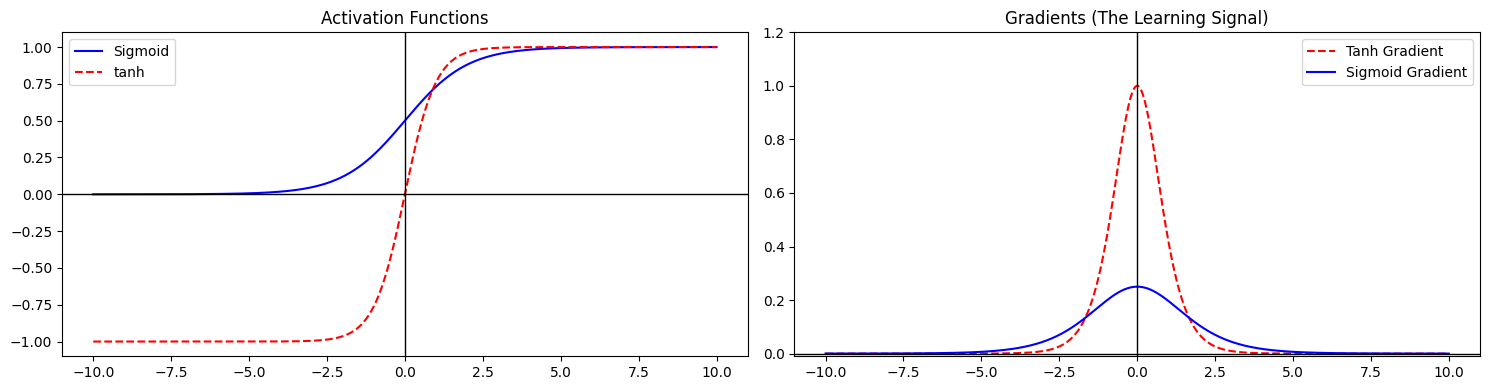

In [ ]:
x = np.linspace(-10,10, 1000)

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(x, sigmoid(x), label="Sigmoid", color="blue")
plt.plot(x, tanh(x), label="tanh", color="red", linestyle="--")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Activation Functions")
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, tanh_gradient(x), label="Tanh Gradient", color="red", linestyle="--")
plt.plot(x, sigmoid_gradient(x), label="Sigmoid Gradient", color="blue")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.ylim(-0.01, 1.2)
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

From the plots above, we can see the advantages over sigmoid. In the activation functions plot, since outputs of the tanh can be negative or positive (mean is closer to zero), the gradients are not restricted in one direction. This acts as a natual normalization for the next layer which allows for much faster convergence. On the gradients plot, we can see that maximum gradient of tanh is 1 at $x=0$ compared to sigmoid which has only max gradient of 0.25. This provides a stronger learning signal initially.

In [ ]:
# visualization of weight updates

def simulate_updates(input_type="positive", steps=150, lr=0.1):
  target_w = np.array([-0.5, 0.8]) # target weights we want to learn
  w = np.array([0.5, -0.2]) # initial weights

  history = [w.copy()]

  for step in range(steps):
    # generate inputs
    if input_type=="positive":
      x = np.random.uniform(0.1, 1, size=2) # always positive (sigmoid)
    else:
      x = np.random.uniform(-1, 1, size=2) # zero-centered (tanh)

    # assume dL/da * sigma'(z) is a constant 1 so the gradient is purely driven by the sign of input to the i-th neuron, x_i
    prediction = w @ x
    target = target_w @ x
    error = prediction - target

    grad = error * x
    w -= lr * grad
    history.append(w.copy())
  return np.array(history)

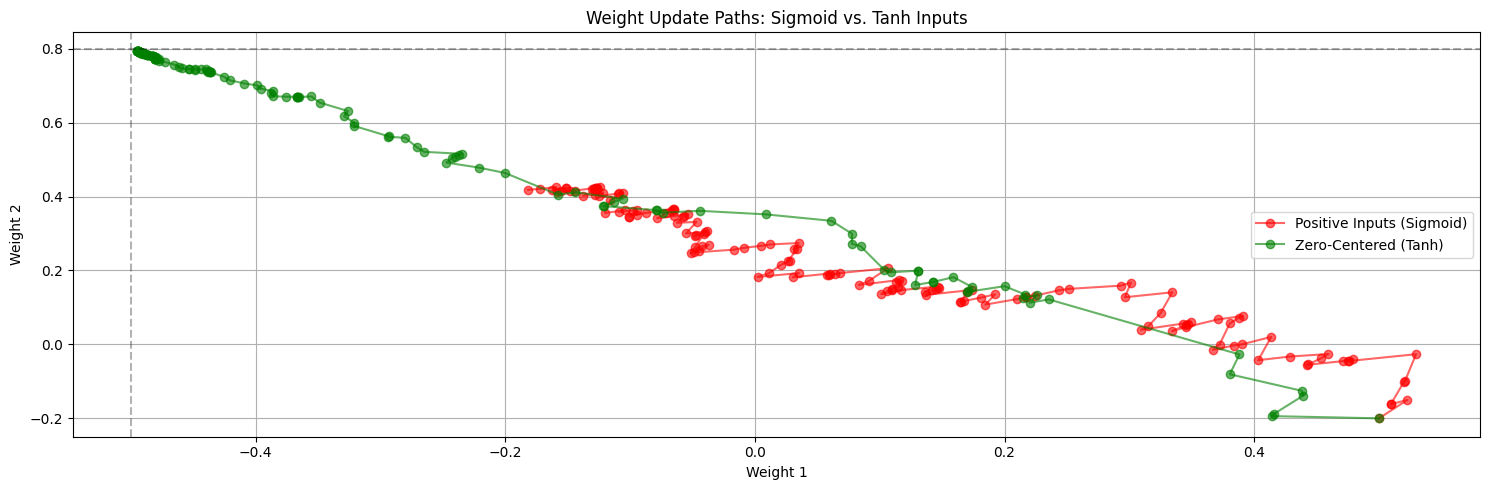

In [ ]:
pos_history = simulate_updates("positive")
cen_history = simulate_updates("zero-centered")

plt.figure(figsize=(15,5))
plt.plot(pos_history[:, 0], pos_history[:, 1], 'r-o', label="Positive Inputs (Sigmoid)", alpha=0.6)
plt.plot(cen_history[:, 0], cen_history[:, 1], 'g-o', label="Zero-Centered (Tanh)", alpha=0.6)
plt.axhline(0.8, color='black', linestyle='--', alpha=0.3) # Target W2
plt.axvline(-0.5, color='black', linestyle='--', alpha=0.3) # Target W1
plt.title("Weight Update Paths: Sigmoid vs. Tanh Inputs")
plt.xlabel("Weight 1")
plt.ylabel("Weight 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We can see from the plot that always positive inputs create a "zig-zag" inefficiency in gradient descent. Because the weight update $\Delta w$ is directly proportional to the input $x$, having only positive inputs forces all weights in a layer to increase or decrease in unison during a single update. If the optimal path requires one weight to increase while another decreases, the model cannot move there directly, instead it must take a taxing indirect route. Zero-centered inputs solve this by allowing inputs to be either positive or negative, giving the gradients the freedom to update weights in any direction independently, which leads to significantly faster and more stable convergence.

Even though tanh is better than sigmoid, it still belongs to the *Saturated* family. As $x$ gets larger, the gradient approaches zero. In deep networks, we still hit the *vanishing gradient* problem.

Because of the vanishing gradient problem shown above, researchers realized that they needed a function that is non-linear and also does not saturate (does not flatten out) for large positive values. This led to the "Moden Era" and the discovery of *Rectified Linear Unit (ReLU)*, which has a constant gradient of 1 for all positive values, ensuring the signal stays strong across hundreds of layers.

## 4. Rectified Linear Unit (ReLU)

ReLU is a piecewise linear function. It mimics the firing of a neuron without the penalty of saturation. It was introduced to solve the vanishing gradient problem.

Mathematically it is defined as:

$$
f(x) = max(0, x)
$$

The derivative (gradient) is beautifully simple:

$$
f'(x) =
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{if } x \leq 0
\end{cases}
$$


In [ ]:
def relu(x):
  return np.maximum(x, 0)

def relu_gradient(x):
  return np.where(x>0,1,0)

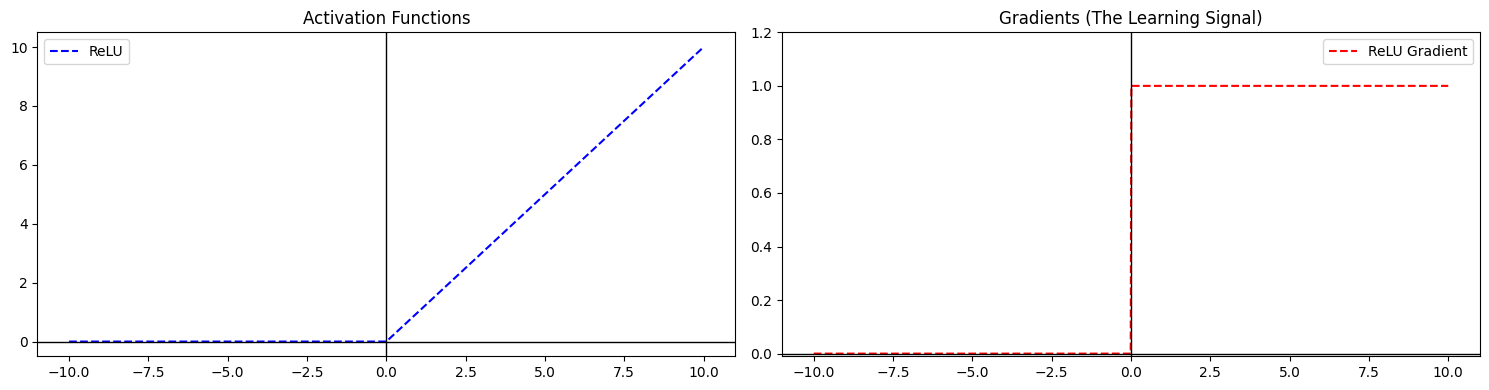

In [ ]:
x = np.linspace(-10,10, 1000)

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(x, relu(x), label="ReLU", color="blue", linestyle="--")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Activation Functions")
plt.legend()
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, relu_gradient(x), label="ReLU Gradient", color="red", linestyle="--")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.ylim(-0.01, 1.2)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# Simulate a 20-layer deep network
layers = 25
input_val = 0.5 # active neuron value

sigmoid_signal = [1.0] # starting gradient
relu_signal = [1.0] # starting gradient
tanh_signal = [1.0]
for i in range(layers):
  # Multiply current signal by the local gradient of the function
  sigmoid_signal.append(sigmoid_signal[-1] * sigmoid_gradient(input_val))
  relu_signal.append(relu_signal[-1] * relu_gradient(input_val))
  tanh_signal.append(tanh_signal[-1] * tanh_gradient(input_val))

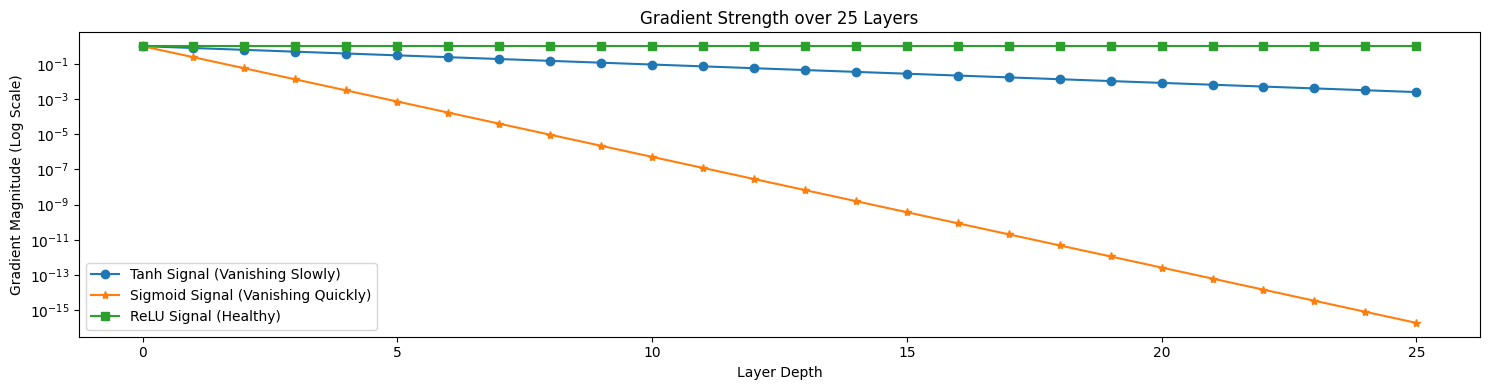

In [ ]:
plt.figure(figsize=(15, 4))
plt.plot(range(layers + 1), tanh_signal, label='Tanh Signal (Vanishing Slowly)', marker='o')
plt.plot(range(layers + 1), sigmoid_signal, label='Sigmoid Signal (Vanishing Quickly)', marker='*')
plt.plot(range(layers + 1), relu_signal, label='ReLU Signal (Healthy)', marker='s')
plt.yscale('log')
plt.title("Gradient Strength over 25 Layers")
plt.xlabel("Layer Depth")
plt.ylabel("Gradient Magnitude (Log Scale)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

For any positive input, the gradient is exactly 1 no matter how many layers we have. The signal stays strong to the very first layer. Another benefit of ReLU is sparsity, that is, it turns off neurons that aren't relevant (outputs 0), which makes the network computationally efficient.

While ReLU solved the vanishing gradient problem, it introduced another fatal flaw for negative inputs. If the weighted sum entering a neuron is negative, the output is zero and the gradient is zero.

$$
weight_{new} = weight_{old} - \eta(0)
$$

The weights do not update. The neuron stops learning entirely. During training, a neuron's weights may drift into a configuration where the weighted sum is always negative. Once this happens, ReLU outputs zero, gradients vanish, and the neuron cannot recover which makes it permanently inactive. It's gradient is stuck at zero.

Now, we needed a function which allows for a small signal to pass even when inputs are negative which lead AI researchers to the dicovery of Leaky ReLU.

## 5. Leaky ReLU

Researchers introduced this activation function to keep those "dead" neurons on life support. Leaky ReLU ensures that even if a neuron is inactive (negative input), it still contributes a small gradient to the learning process.

Instead of mapping all negative values to zero, we multiply them by a small non-zero constant $\alpha$ typically 0.01 to keep the learning going.

Mathematically,

$$
f(x) = max(\alpha x, x)
$$

The derivative (gradient) is where the magic happens:

$$f'(x) = \begin{cases}
1 & \text{if } x > 0 \\
\alpha & \text{if } x \leq 0
\end{cases}
 $$


In [ ]:
def leaky_relu(x, alpha=0.01):
  return np.maximum(alpha*x, x)

def leaky_relu_gradient(x, alpha=0.01):
  return np.where(x>0,1,alpha)

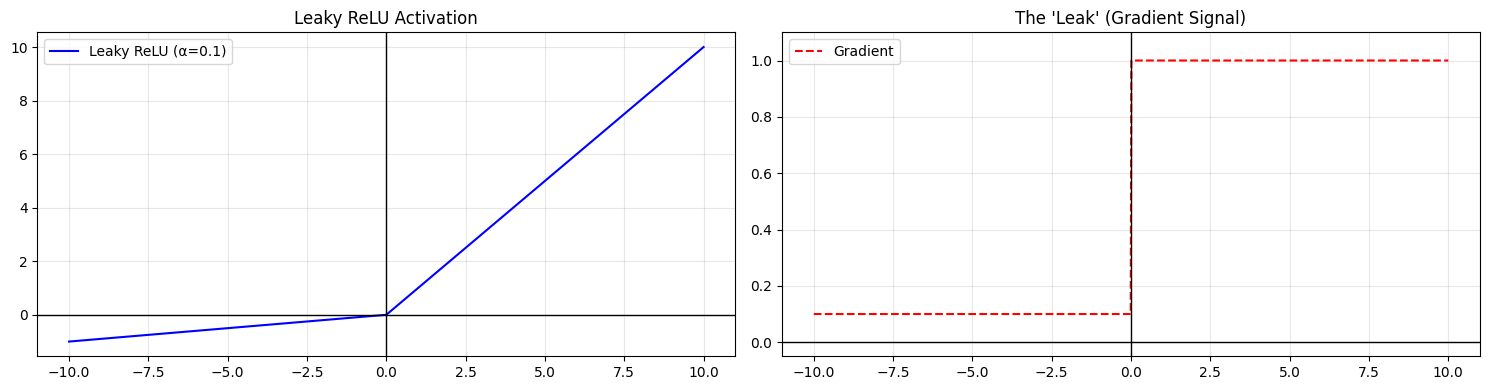

In [ ]:
x = np.linspace(-10, 10, 1000)

plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(x, leaky_relu(x, alpha=0.1), label=f"Leaky ReLU (α={0.1})", color="blue")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Leaky ReLU Activation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, leaky_relu_gradient(x, alpha=0.1), label="Gradient", color="red", linestyle="--")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.ylim(-0.05, 1.1)
plt.title("The 'Leak' (Gradient Signal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The leak is to ensure that even when a neuron is off ($x < 0$), it still passes a small gradient back during backpropagation. This prevents the *Dying ReLU* problem where neurons get stuck at zero and never update again.

Beacause $\alpha \neq 0$, the gradient never truly dissappears. Even cold neurons can eventually pushed back into the positive range if the loss function demand it. Leaky ReLU allows the network to maintain some degree of information from negative signals, which might be useful in certain data distributions.

Even though Leaky ReLU is an improvement, it is not a perfect activation function. $\alpha$ is a hyperparameter than we have to choose manually. Both ReLU and Leaky ReLU have a sharp corner at zero. This lack of smoothness can sometimes make the optimization landscape more rugged than it need to be.

So, who decides the slope $\alpha$?

In standard Leaky ReLU, $\alpha$ is a constant chosen by the researcher, but we can also make it a trainable parameter which changes the game and introduces a new activation function called Parametric ReLU.


## 6. PReLU (Parametric ReLU)

In PReLU, $\alpha$ is not fixed. It is a variable that the network learns through backpropagation just like it learns weights and biases.

Mathematically, the function looks identical to Leaky ReLU:

$$
f(x) = max(\alpha x, x)
$$

The derivative with respect to the input $x$ is:

$$
\frac{\partial f}{\partial x} =
\begin{cases} 1 & \text{if } x > 0 \\
\alpha & \text{if } x \leq 0
\end{cases}
$$

Because $\alpha$ is now a parameter, we also calculate the derivative with respect to $\alpha$.

$$
\frac{\partial f}{\partial \alpha} =
\begin{cases} 0 & \text{if } x > 0 \\
x & \text{if } x \leq 0
\end{cases}
$$

This allows the optimizer like Adam or SGD to update $\alpha$ at every iteration.


The advantage of PReLU is that in some layers, the netowrk might find that a large leak ($\alpha= 0.2$) is beneficial. In others, it might learn that a standard ReLU ($\alpha = 0$) is optimal. We no longer need to run various experiments just to find the right $\alpha$ and it only adds a single extra parameter per channel/layer meaning the computational overhead is almost zero.

In [ ]:
def prelu(x, alpha):
  # return np.maximum(alpha*x, x)
  return np.maximum(0, x) + alpha*np.minimum(0, x)

def prelu_grad_alpha(x):
  return np.where(x>0, 0, x) # This is the gradient that tells the network how to change alpha

def prelu_grad_input(x, alpha=0.01):
  return np.where(x>0, 1, alpha)

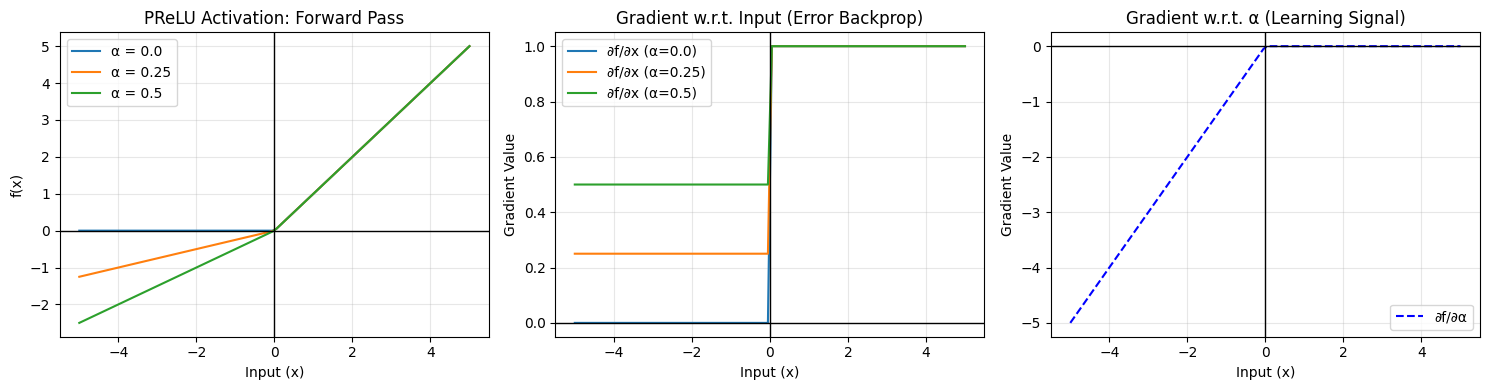

In [ ]:
# Simulating the learning of alpha
x = np.linspace(-5, 5, 100)
alphas = [0.0, 0.25, 0.5]

plt.figure(figsize=(15, 4))

# Subplot 1: The Activation Function (Forward Pass)
plt.subplot(1, 3, 1)
for a in alphas:
  plt.plot(x, prelu(x, a), label=f'α = {a}')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("PReLU Activation: Forward Pass")
plt.xlabel("Input (x)")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Gradient w.r.t. Input (Backpropagation)
plt.subplot(1, 3, 2)
for a in alphas:
  plt.plot(x, prelu_grad_input(x, a), label=f'∂f/∂x (α={a})')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradient w.r.t. Input (Error Backprop)")
plt.xlabel("Input (x)")
plt.ylabel("Gradient Value")
plt.legend()
plt.grid(alpha=0.3)

# Subplot 3: Gradient w.r.t. Alpha (Parameter Update)
plt.subplot(1, 3, 3)
plt.plot(x, prelu_grad_alpha(x), label='∂f/∂α', color='blue', linestyle='--')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradient w.r.t. α (Learning Signal)")
plt.xlabel("Input (x)")
plt.ylabel("Gradient Value")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

As a researcher, we must be cautious. PRelu adds more parameters. If the dataset is very small, the network might use these flexible slopes to memorize the noise in the data rather than learning general patterns.

PReLU solved the fixed hyperparamter problem but we still have the sharp "kink" at zero. In optimization, sharp corners can cause the gradient to jump around. This leads us to our next evolution of activation function *ELU* (Exponential Linear Unit) which tries to combine the benefits of ReLU with a smooth continuous curve.

Note: PReLU was critical in achieving the first human-level performance on ImageNet classification.

## 7. Exponential Linear Unit (ELU)

As an AI researcher, we realized that neural networks are essentially hikers trying to find the bottom of a mountain (the Cost Function). ReLU and PReLU create jagged cliffs at $x=0$. ELU was designed to turn that cliff into a smooth slide, making the hiker's journey much more stable.

ELU was introduced by CLevert et al. (2015) which replaced the straight line of leaky ReLU for negative values with an exponential curve.

The function is defined as:

$$
f(x) =
\begin{cases}
x & \text{if } x > 0 \\
\alpha(e^x - 1) & \text{if } x \leq 0
\end{cases}
$$

The derivative of this function is:

$$
f'(x) =
\begin{cases}
1 & \text{if } x > 0 \\
f(x) + \alpha & \text{if } x \leq 0 \end{cases}$$

The exponential part is important because unlike ReLU, ELU can output negative values which pushes the mean activation closer to zero speeding up the learning (similar to why Tanh was better than Sigmoid). Unlike Leaky Relu which goes to negative infinity, ELU saturates to $-\alpha$ as $x$ becomes very negative which makes the model more robust to noise in the negative input range. And if $\alpha=1$, the function is perfectly smooth (continuously differentiable) at $x=0$ whereas ReLU has a hard kink. Also note that ELU is computationally expensive due to $e^x$

Note: The $\alpha$ hyperparameter is usually fixed at 1

In [ ]:
def elu(x, alpha=1.0):
  return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_gradient(x, alpha=1.0):
  return np.where(x > 0, 1.0, alpha * np.exp(x))

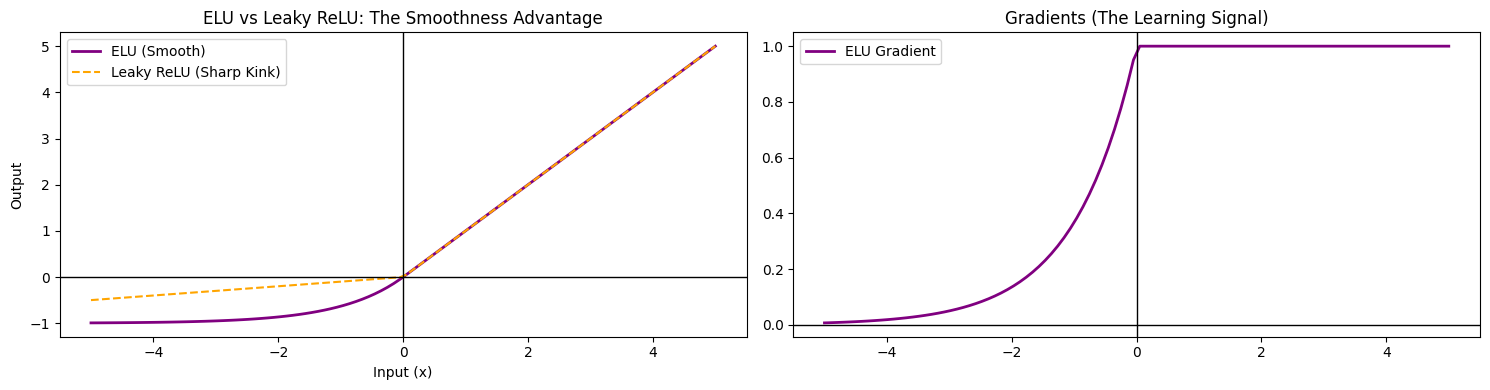

In [ ]:
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(x, elu(x, alpha=1), label='ELU (Smooth)', color='purple', lw=2)
plt.plot(x, leaky_relu(x, alpha=0.1), label='Leaky ReLU (Sharp Kink)', color='orange', linestyle='--')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("ELU vs Leaky ReLU: The Smoothness Advantage")
plt.xlabel("Input (x)")
plt.ylabel("Output")
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, elu_gradient(x), label='ELU Gradient', color='purple', lw=2)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


ELU is great but it still has a fixed $\alpha$. What if we could combine the self-normalizing properties of Tanh with the non-vanishing gradients of ReLU automatically?

This leads us to a super powerful version fo ELU called *SELU* (Scaled Exponential Linear Unit), which is the key to training very deep Self-Normalizing Neural Networks (SNNs).

As a researcher, one of the biggest headache is *Internal Covariate shift* that is the tendency for the distribution of neuron activations to drift as we go deeper into a network. Usually, we fix this with Batch Normalization. However, SELU builds the normalization directly into the math of the activation function itself.

## 8. SELU (Scaled Exponential Linear Unit)

SELU is a variant of ELU, but it is multiplied by a scaling factor $\lambda$.

The function is defined as:

$$
f(x) = \lambda
\begin{cases} x & \text{if } x > 0 \\
\alpha(e^x - 1) & \text{if } x \leq 0
\end{cases}
$$

For SELU to work its self-normalizing magic, the values of $\alpha$ and $\lambda$ are not hyperparameters we choose. They are fixed constants derived by *Klambauer et al.* (2017) using fixed point analysis.
- $\alpha \approx 1.6733$
- $\lambda \approx 1.0507$

To get the derivative $f'(x)$, we differentiate each piece with respect to $x$.

For $x > 0$, the derivative of $\lambda x$ is simply $\lambda$. And for $x \le 0$, the derivatve of $\lambda \alpha(e^x - 1)$ is $\lambda \alpha e^x$ since the derivative of $e^x$ is $e^x$ and the constant -1 disappears we have,

$$
f'(x) =
\begin{cases} \lambda & \text{if } x > 0 \\
\lambda \alpha e^x & \text{if } x \leq 0
\end{cases}
$$

This is a breakthrough in AI because of the following reasons:
- Fixed Mean and Variance: If we initialize the weights correctly (using *LeCun Normal Initialization)*, the activations will automatically converge toward a mean of 0 and a variance of 1 as they pass through each layer.
- No Batch Norm Needed: We can train deep networks without Batch Normalization layers which simplifies the architecture and can speed up training.
- Stability: It prevents both vanishing and expliding gradients by keeping the internal signal at a steady volume.

Note that even though SELU is powerful, it is picky. For the self-normalization to occur, we must use *LeCun Normal* weight initialization. It works best in standard feed-forward networks (MLPs) and the standard dropout breaks the normalization so we need to use *Alpha Dropout* instead.

*Terminology Alert: Covatiate Shift* While the term covariate shift usually refers to changes in input data between training and testing, in the context of neural network architecture, we are often talking about Internal Covariate Shift (ICS). Imagine a deep neural network where each layer is trying to learn. As the weights in Layer 1 update, the distribution of its outputs changes. Layer 2, which takes those outputs as inputs suddently has the rugh pulled out from under it, the data it was learning to process has shifted. This creates a moving target for every subsequent layer forcing them to constantly adapt to new distributions. This instability often leads to vanishing or exploding gradients and slower convergence because layers cannot settle on stable patterns.

In [ ]:
# how scaling factor lambda changes the shape compared to standard ELU

def selu(x):
  alpha = 1.6732632423543772848170429916717
  lmda = 1.0507009873554804934193349852946
  return lmda * np.where(x >0, x, alpha * (np.exp(x) - 1))

def selu_gradient(x):
  alpha = 1.6732632423543772848170429916717
  lmda = 1.0507009873554804934193349852946
  return np.where(x>0, lmda, lmda*alpha*np.exp(x))

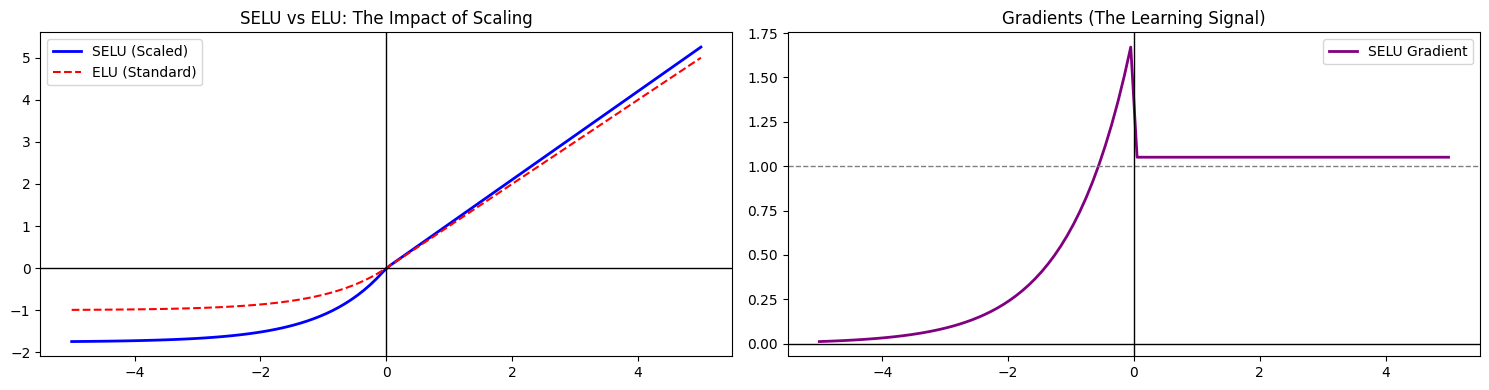

In [ ]:
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(15, 4))

plt.subplot(1,2,1)
plt.plot(x, selu(x), label='SELU (Scaled)', color='blue', lw=2)
plt.plot(x, elu(x), label='ELU (Standard)', color='red', linestyle='--')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("SELU vs ELU: The Impact of Scaling")
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, selu_gradient(x), label="SELU Gradient", color="purple", lw=2)
plt.axhline(0, color='black', lw=1)
plt.axhline(1, color='grey', lw=1, linestyle="--")
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

From the gradient plot, we can see the following:
- Saturation: For very large negative values, the derivative approaches 0 which can lead to vanishing gradients if not managed properly.
- Slope: For positive values, the gradient is slightly greater than 1 ($\lambda \approx 1.0507$) which helps gradients from vanishing in deep architecture
- Discontinuity: While the function is continuous, there is a step change in the derivative at $x = 0$ shifting from $\lambda \alpha \approx 1.75$ to $\lambda \approx 1.05$

In the SELU vs ELU plot, we see that SELU has a slope greater than 1 for positive values due to $\lambda$. This extra push is what allwos it to counteract the shrinking variance that typically happens in deep networks.

In [ ]:
# 20 layer ReLU vs SELU
# in standard network like ReLU, the variance oftern explodes or vanishes as we go deeper.
# In SNN using SELU, these values should stay remarkably close to (0,1)

def test_normalization(activation_fn, init_type="lecun"):
  layers = []
  input_dim = 512

  for _ in range(20):
    layer = nn.Linear(input_dim, input_dim)
    if activation_fn == nn.SELU:
      nn.init.normal_(layer.weight, std=(1/input_dim)**0.5) # LeCun Normal: mean=0, std = sqrt(1/fan_in)
    else:
      nn.init.kaiming_normal_(layer.weight)
    layers.append(layer)
    layers.append(activation_fn())
  model = nn.Sequential(*layers)
  x = torch.randn(100, input_dim) # create standardized input (mean 0, std 1)
  # track activation layer by layer
  means = []
  stds = []
  current_x = x
  for layer in model:
    current_x = layer(current_x)
    if not isinstance(layer, nn.Linear): # record after activation
      means.append(current_x.mean().item())
      stds.append(current_x.std().item())

  return means, stds

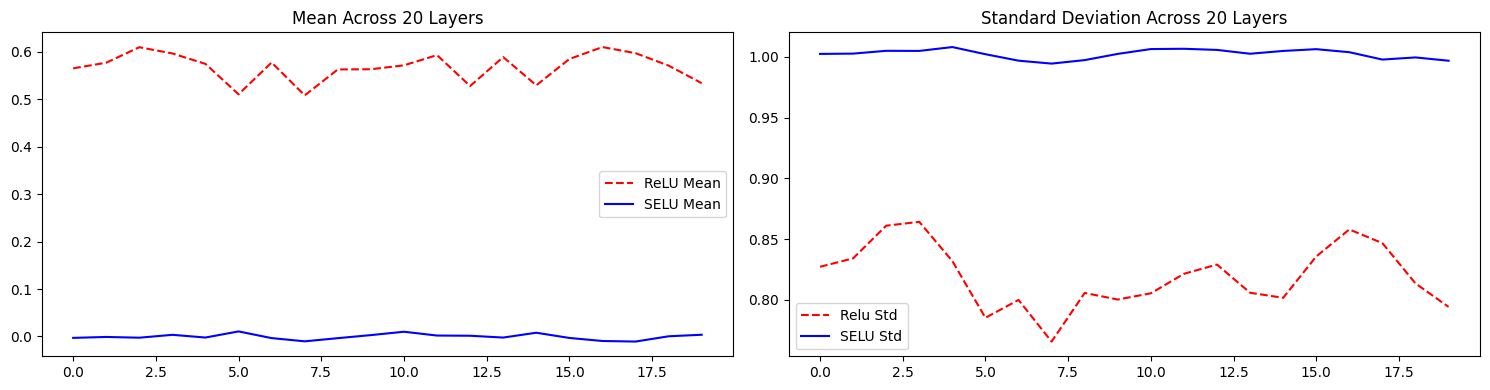

In [ ]:
relu_means, relu_stds = test_normalization(nn.ReLU)
selu_means, selu_stds = test_normalization(nn.SELU)

plt.figure(figsize = (15, 4))

plt.subplot(1,2,1)
plt.plot(relu_means, label='ReLU Mean', color = 'red', linestyle = "--")
plt.plot(selu_means, label="SELU Mean", color='blue')
plt.title("Mean Across 20 Layers")
plt.legend()

plt.subplot(1,2,2)
plt.plot(relu_stds, label="Relu Std", color='red', linestyle="--")
plt.plot(selu_stds, label="SELU Std", color='blue')
plt.title("Standard Deviation Across 20 Layers")
plt.legend()
plt.tight_layout()
plt.show()

From the plots above, we can see that the mean drift upwards or standard deviation fluctuate wildly. This is the shift that makes deep networks hard to train without Batch Norm. The SELU plot looks nearly flat. Even at 20, the data looks almost exactly like it did at layer 1. Note that for SELU, if we use standard Xavier or He initialization, the self-normalizing property breaks. SELU requires LeCun Normal initialization to ensure the fixed-points remains at (0,1).

Hence, by keeping the distribution stable (mean close to zero and standard deviation close to 1) automatically, SELU removes the need for BATCH normalization layers. This makes the network computationally faster and allows it to perform consistently regardless of the batch size.

As mentioned above, to keep the self-normalizing property intact during training , we cannot use standard dropout since it sets neurons to zero which shifts the mean of the remaining activations toward zero and changes the variance, destroying the internal stablility of SELU worked so hard to create. So, we need to use alpha dropout. It randomly sets activations to the negative saturation value of SELU ($-\lambda \alpha$) rather than zero, then applies a sclaing factor to ensure the mean variance remain at (0,1).

In [ ]:
# robust SNN using SELU and alpha dropout

class SelfNormalizingNet(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, dropout_prob=0.1):
    super().__init__()
    layers = []
    in_features = input_size
    for _ in range(num_layers):
      layer = nn.Linear(in_features, hidden_size) # linear layer
      nn.init.normal_(layer.weight, std=(1.0/in_features)**0.5) # LeCun initialization
      nn.init.zeros_(layer.bias)

      layers.append(layer)

      layers.append(nn.SELU()) # selu activation
      layers.append(nn.AlphaDropout(p=dropout_prob)) # alpha dropout that maintains mean and variance

      in_features = hidden_size
    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)

In [ ]:
model = SelfNormalizingNet(input_size=784, hidden_size=256, num_layers=20)
sample_input = torch.randn(32, 784) # standardized input
output = model(sample_input)

print(f"Output Mean: {output.mean().item():.2f}")
print(f"Output Std: {output.std().item():.2f}")

Output Mean: 0.01
Output Std: 0.99


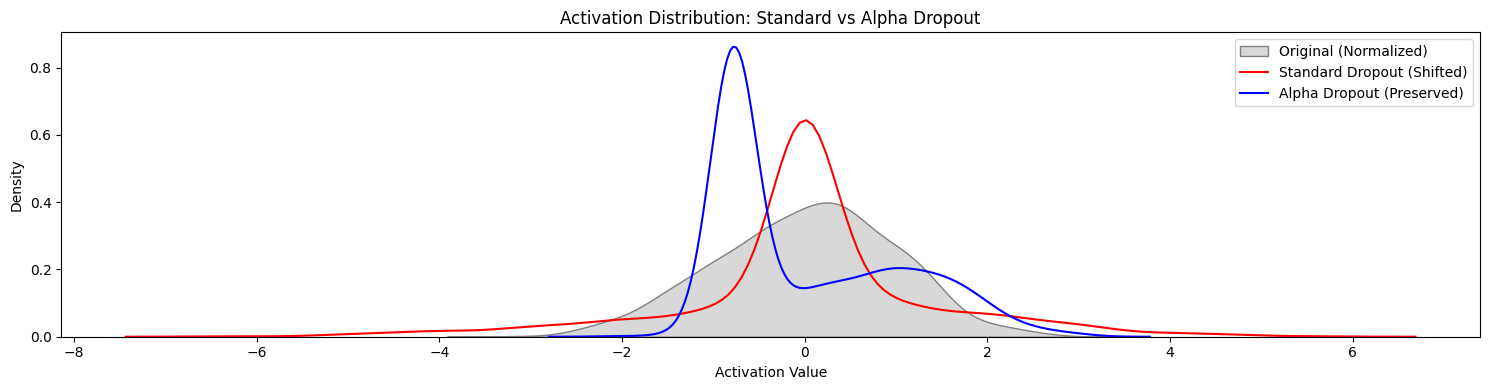

Original -> Mean: 0.0186, Std: 0.9770
Std Dropout -> Mean: 0.0283, Std: 1.4186
Alpha Dropout -> Mean: -0.0016, Std: 1.0075


In [ ]:
# internal covariate shift in real time
# compare how a batch of data looks after passing through standard Dropout vs Alpha Dropout

x = torch.randn(1000)

standard_dropout = nn.Dropout(p=0.5)
x_standard = standard_dropout(x)

alpha_dropout = nn.AlphaDropout(p=0.5)
x_alpha = alpha_dropout(x)

plt.figure(figsize=(15, 4))

sns.kdeplot(x.numpy(), label = "Original (Normalized)", fill=True, color="grey", alpha=0.3)
sns.kdeplot(x_standard.numpy(), label="Standard Dropout (Shifted)", color = "red")
sns.kdeplot(x_alpha.numpy(), label="Alpha Dropout (Preserved)", color = "blue")

plt.title("Activation Distribution: Standard vs Alpha Dropout")
plt.xlabel("Activation Value")
plt.ylabel("Density")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

print(f"Original -> Mean: {x.mean():.4f}, Std: {x.std():.4f}")
print(f"Std Dropout -> Mean: {x_standard.mean():.4f}, Std: {x_standard.std():.4f}")
print(f"Alpha Dropout -> Mean: {x_alpha.mean():.4f}, Std: {x_alpha.std():.4f}")

From the plot, we observe the following:
- Spike at Zero: Standard dropout creates a massive spike at 0. Because it rescales the other values to keep the mean roughtly the same, the standard deviation usually explodes (often doubling)
- Tail Preservation: Alpha dropout maintains a distribution shape that while having a small spike at the SELU saturation point, keeps the overall mean and variance almost indentical to the input.

While SELU is mathematically elegant, the world of *Large Language Models (LLMs)* and *Vision Transformers (ViTs)* jas largely moved toward a different family of functions based on "Gating".

In the evolution of activation functions, we have now transitions from manually engineered curves like ELU and mathematically derived constants like SELU to automatic discovery.

Now we will talk about *Swish* activation function. The story of Swish is fascinating. Researchers at Google did not derive this with pen and paper. Instead, they used a reinforcement learning search to find the best performing activation function across various datasets. The result was a function that looks like a smooth ReLU with a dip.

## 9. Swish

Swish is defined by a simple multiplication of the input by its sigmoid which is known as Self-Gating.

Mathematically, it is defined as:

$$
f(x) = x \sigma(\beta x)
$$

where:
- $\sigma(z) = \frac{1}{1 + e^{-x}}$

Why Swish is better than ReLU?

- Smoothness: Swiss is continously differentiable everywhere. This makes the loss landscape smoother and easier for the optimizer to navigate.
- Non-Monotonicity: Unlike ReLU, which is flat for $x< 0$, Swish has a small dip where the ouput decreqases even as the input increases slightly.
- Unbounded Above, Bounded Below: Like ReLU, it does not saturate for large positive values (preventing vanishing gradients), but it provides a smooth soft floor for negative values.

The derivative of Swish is:

$$
f'(x) = \sigma(\beta x) + \beta x \sigma(\beta x)(1 - \sigma(\beta x))
$$

$$
f'(x) = \beta f(x) + \sigma(\beta x)(1 - \beta f(x))
$$

This gradient ensures that the network receives signals even for slightly negative inputs, avoiding the hard death of standard ReLU neurons.

In [ ]:
def swish(x, beta=1.0):
  return x * sigmoid(beta * x)

def swish_gradient(x, beta = 1):
  bx = beta * x
  s = sigmoid(beta * x)
  return s + bx * s * (1 - s)

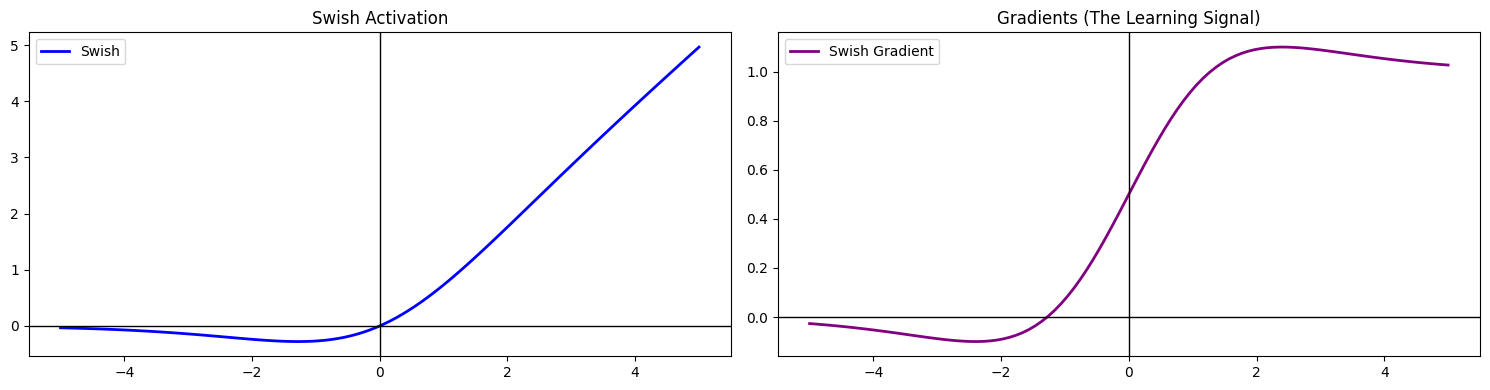

In [ ]:
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(15, 4))

plt.subplot(1,2,1)
plt.plot(x, swish(x, beta=1.0), label='Swish', color='blue', lw=2) # change beta to see the change
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Swish Activation")
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, swish_gradient(x, beta = 1), label="Swish Gradient", color="purple", lw=2) # change beta to see the change
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

The Swish Activation plot shows a unique dip below zero,  a non-monotonic feature that allows the model to preserve and learn from small negative values rather than discarding them. Meanwhile, the Gradient plot reveals the learning signal. Unlike ReLU which hits a flat zero for all negative inputs, Swish maintains a small, leaky gradient in the negative domain. This ensures that neurons don't die during training which provides a more stable and fluid path for the optimization algorithm to finsd the best weights.

Swish proved that gating works. However, in the world of Transformers (BERT, GPT, Llama), a cousin of Swish has become the industry standard which is GELU (Gaussian Error Linear Unit).

While Swish uses the Sigmoid for gating, GELU uses the Cumulative Distribution Function (CDF) of a Gaussian distribution.

However when training models with billions of paramters like GPT-4, calculating the exact Gaussian integral for every single neuron activation is computationally expensive so we use the approximation.

## 10. GELU (Gaussian Error Liner Unit)

ReLU weights an input by zero or one depending on its sign. GELU weights an input by its probability of being dropped. It scales the input $x$ by the cumulative distribution function (cdf) of the standard normal distribution.

$$
GELU(x) = x P(X \le x) = x \Phi(x)
$$

where $\Phi (x)$ is the standard gaussian cdf. Since, we cannot solve the integral of the gaussian distribution using basic algebra, we rely on a special tool caleed the error function. The error function is the enginer inside the Gaussian cdf. It essentially calculates the area under the bell curve to tell us the probability that a measurement falls within a certain range.

$$
\Phi(x) = \frac{1}{2} \Big[ 1 + erf(\frac{x}{\sqrt2}) \Big]
$$

where erf stands for the Error Function or Gauss error function. It is a special function that appears frequently in probability, statistics and partial differential equaltions. While it looks a bit intimidating, it essentially helps us calculate the area under a Bell Curve (the normal distribution). The error function tells us the probability what a measurement affected by random errors falls within a certain range. Mathematically, it is defined as:

$$
{erf}(x) = \frac{2}{\sqrt{\pi}} \int_{0}^{x} e^{-t^2} dt
$$

The characteristics of this function are:
- Range: The output of $erf(x)$ always stays between -1 and 1.
- Symmetry: It is an odd function, meaning $erf(-x) = -erf(x)$
- Asymptotes: As $x$ gets very large, $erf(x)$ approaches 1. As x gets very small (neagtive), it approaches -1.

The derivative of GELU is as follows:

$$
\frac{d}{d x}GELU(x) = \Phi(x) + \frac{x}{\sqrt(2\pi)} e ^{-\frac{x^2}{2}}
$$


Computing the error function is slow on GPUs hence in the original paper, Dan Hendrycks proposed two fast approximates that are used in almost all LLM codebases like hugging face or metratron-lm.

The most common version seen in BERT and early GPT models is the sigmoid approximation (the tanh version).

$$
GELU(x) \approx 0.5x(1 + tanh \Big[ \sqrt\frac{2}{\pi}(x + 0.044715 x^3) \Big]
$$

When speed is the absolute priority, the simple sigmoid approximation is used:

$$
GELU(x) \approx x \sigma(1.702x)
$$

The derivative of approximation is bit involved so we skip that here.


Now, the question aries on why LLMs use GELU? The reasons are discussed below:
- Gradient Continuity: Unlike, ReLU, GELU has a non-zero gradient for all negative values, but it is much smaller. It allows the model to explore the negative space without the gradient exploding or vanishing instantly.
- The S-Curve at the Origin: Near zero, GELU is much smoother than even ELU. This smoothness is crucial for the stable training of deep transformer blocks where small variations in attention weights can lead to massive shifts in the output.

In [ ]:
# Exact vs approximations

def exact_gelu(x):
  return 0.5 * x * (1 + erf(x/np.sqrt(2)))

def approx_gelu(x):
  # tanh based approximaiton used in GPT/BERT
  return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def exact_gelu_grad(x):
  cdf = 0.5 * (1 + erf(x / np.sqrt(2)))
  pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
  return cdf + x * pdf

def approx_gelu_grad(x):
  k = np.sqrt(2 / np.pi)
  inner = k * (x + 0.044715 * x**3)
  tanh_out = np.tanh(inner)

  # Derivative of the inner term w.r.t x
  inner_deriv = k * (1 + 0.134145 * x**2)

  return 0.5 * (1 + tanh_out) + (0.5 * x * (1 - tanh_out**2) * inner_deriv)

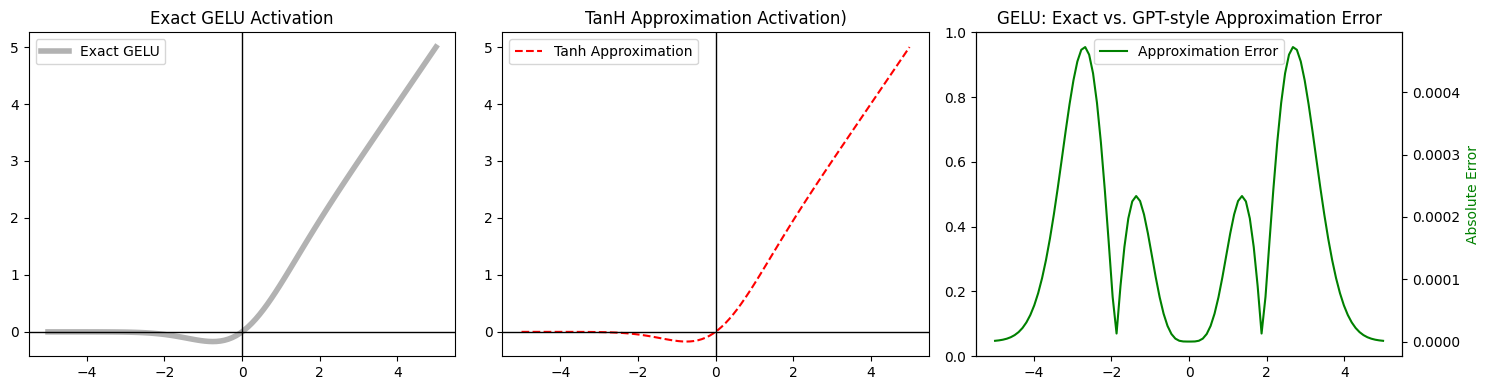

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.plot(x, exact_gelu(x), label='Exact GELU', color='black', lw=4, alpha=0.3)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Exact GELU Activation")
plt.legend()
plt.grid(False)

plt.subplot(1,3,2)
plt.plot(x, approx_gelu(x), label='Tanh Approximation', color='red', linestyle='--')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("TanH Approximation Activation)")
plt.legend()
plt.grid(False)

plt.subplot(1,3,3)
plt.twinx()
plt.plot(x, np.abs(exact_gelu(x) - approx_gelu(x)), label='Approximation Error', color='green')
plt.title("GELU: Exact vs. GPT-style Approximation Error")
plt.ylabel("Absolute Error", color='green')
plt.legend()
plt.tight_layout()
plt.show()

We can see from the error plot that the error is practically zero which is why we can safely use the approximation in production without hurting model performance.

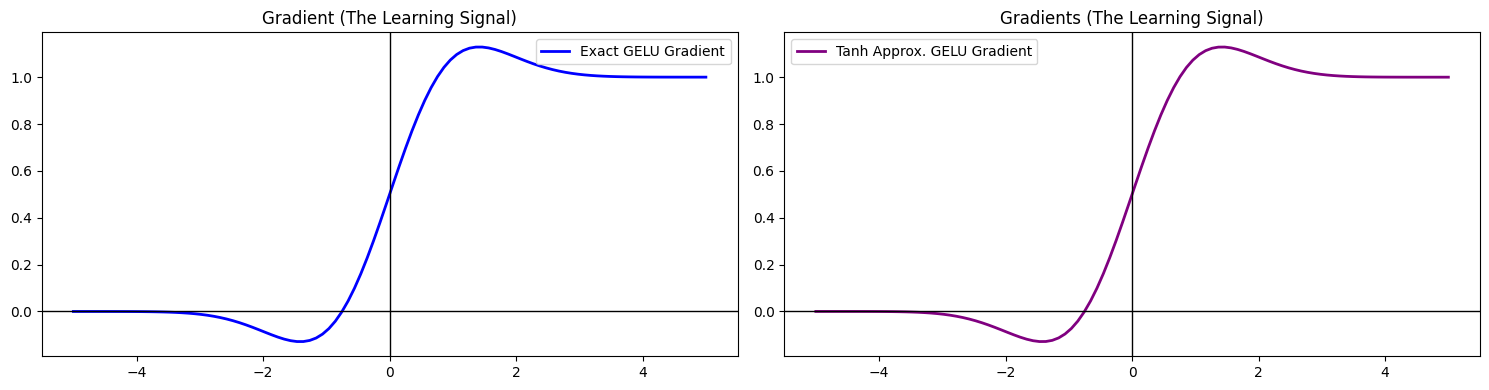

In [ ]:
plt.figure(figsize=(15, 4))
plt.subplot(1,2,1)
plt.plot(x, exact_gelu_grad(x), label='Exact GELU Gradient', color='blue', lw=2) # change beta to see the change
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradient (The Learning Signal)")
plt.legend()
plt.grid(False)

plt.subplot(1,2,2)
plt.plot(x, approx_gelu_grad(x), label="Tanh Approx. GELU Gradient", color="purple", lw=2) # change beta to see the change
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Gradients (The Learning Signal)")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

Now, we have covered the path from the primitive step function to the statistically grounded GELU. However, there is one more variation currently dominating the "Llama-era" of models: GLU (Gated Linear Units) and specially SwiGLU. This is not just an activation function, it is a structural change to how neurons multiply.

As an AI researcher, reaching SwiGLU is like arriving at the current state of the art. If we look at reports for Llama2, Llama3, PaLM we won't just see an activation function, we see a Gated Linear Unit (GLU) varient. SwiGLU is not just a curve, it is a mathematical operation involving two different linear projections.

## 11. SwiGLU (Swish-Gated Linear Unit)

Standard activations like ReLU or GELU follow the format: $f(Wx + b)$. SwiGLU changes the architecture of a neuron. It splits the input into two parts and applies a Swish activation to one and then multiplies it bt the other.

The formula for SwiGLU layer is:

$$
SwiGLU(x, W, V, b, c) = Swish_{\beta}(xW + b)  \otimes (xV + c)
$$

where:
- $W$ and $V$ are two different weight matrices
- $\otimes$ represents element-wise multiplication (Hadamard product)
- $Swish(z) = z \sigma(z)$

The function operates on a vector $x$ using two linear transformations $W$ and $V$.

To keep the math simple, let's define two intermediate variable:
- The Gates: $g = Swish_{\beta} (xW + b)$
- The Linear Transformation: $l = xV + c$

So, $SwiGLU = gl$

Now to find the derivative with respect to the input, we use the product rule:

$$
\frac{d}{dx}(g \cdot l) = g' \cdot l + g \cdot l'
$$

- Derivative of the Gate ($g'$): Since the gate is a Swish function $(x \sigma(\beta x))$, its derivative is: $Swish'(x) = Swish(x) + \sigma(x) (1 - Swish(x))$, assuming $\beta = 1$ for simplicity which is a standard.
- Derivative of the Linear part $(l')$: This is just the weight matrix $V$.

When we piece it together for backpropagation in a neural network, the gradient flowing back through a SwiGLU layers looks like this:
- For the Linear branch: The gradient is weighted by the output of the Swish gate
- For the Swish branch: The gradient is weighted by the linear branch, multiplied by the derivative of Swish

The reasons behind why SwiGLU is a LLM king is discussed below:
- Dynamic Gating: One branch $(xV + c)$ acts as a gate for the other. It allows the model to decide not just if a signal should pass, but how much of it is relevant based on a second learned context.
- Increased Expressivity: Because it uses two weight matrices instead on one, it has more parameters and can learn more complex non-linear relationships than a simple ReLU or GELU.
- Superior Convergence: In the paper *"GLU Variants import Transformer"* (Shazeer, 2020), it was shown that SwiGLU consistently outperforms almost every other activation function in terms of final perplexity/loss in transformers.

In [ ]:
# simplified version using NumPy to show the Dual Path logic

def swish(x):
  return x * (1 / (1 + np.exp(-x)))

def swiglu(x, W, V, b, c):
  gate = swish(np.dot(x, W) + b) # Path 1: Swish activated
  linear = np.dot(x, V) + c # Path 2: Linear projection
  return gate * linear # The "Gated" output

input_data = np.random.randn(1, 128)  # Single token embedding
W = np.random.randn(128, 256)        # Weight matrix 1
V = np.random.randn(128, 256)        # Weight matrix 2
b = np.zeros(256)
c = np.zeros(256)

output = swiglu(input_data, W, V, b, c)
print(f"Output shape: {output.shape}")

Output shape: (1, 256)


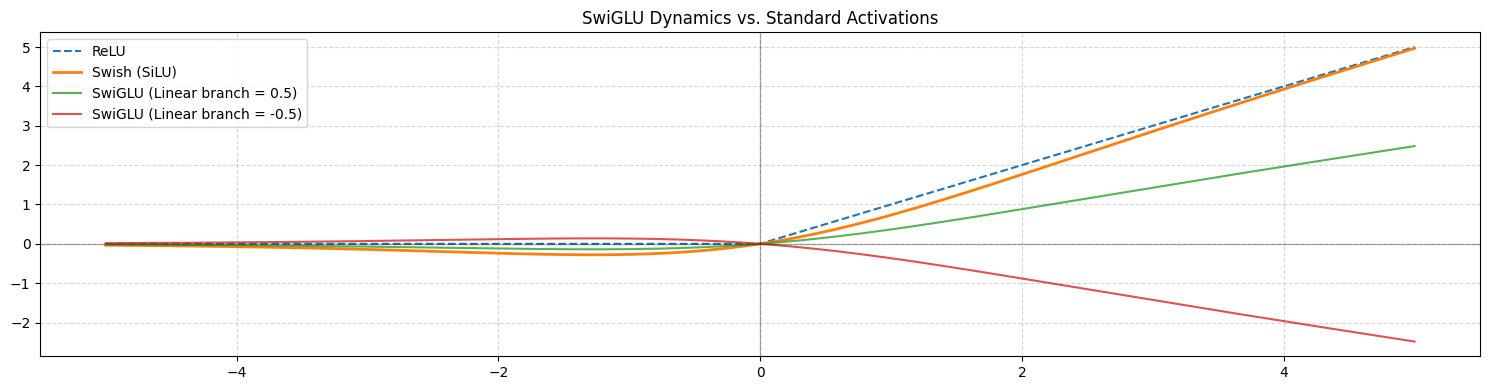

In [ ]:
# visualizing the Gating Effect
# since SwiGLU depends on two learned projections (W and V), its shape isn't fixed like ReLU
# it changes based on what the model learns.

# to see this, we simulate 1D input and look at how different gate states affect the output

x = np.linspace(-5, 5, 1000)

y_relu = np.maximum(0, x)
y_swish = swish(x)

# For SwiGLU, we simulate the 'linear' branch (xV) as a constant or a gradient to see how it "gates" the Swish branch.
y_swiglu_pos = swish(x) * 0.5  # Gate dampened
y_swiglu_neg = swish(x) * -0.5 # Gate inverted

plt.figure(figsize=(15, 4))
plt.plot(x, y_relu, label='ReLU', linestyle='--')
plt.plot(x, y_swish, label='Swish (SiLU)', linewidth=2)
plt.plot(x, y_swiglu_pos, label='SwiGLU (Linear branch = 0.5)', alpha=0.8)
plt.plot(x, y_swiglu_neg, label='SwiGLU (Linear branch = -0.5)', alpha=0.8)
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.title("SwiGLU Dynamics vs. Standard Activations")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def swish(x):
  return x * sigmoid(x)

def swish_derivative(x):
  sig = sigmoid(x)
  return sig + x * sig * (1 - sig)

def swiglu_proxy(x):
  return swish(x) * x  # Proxy for SwiGLU(x) = Swish(x) * x (Assuming W=V=I)


def swiglu_proxy_derivative(x):
  sig = sigmoid(x)
  return 2 * x * sig + x**2 * sig * (1 - sig)  # Derivative of x^2 * sigmoid(x)

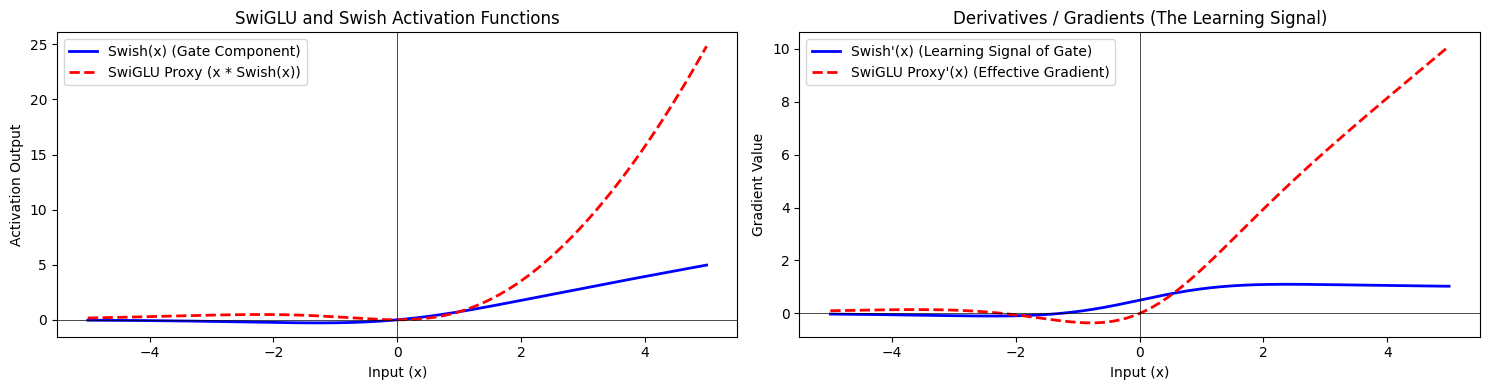

Max gradient of Swish: 1.0998
Gradient of Swish at x=0: 0.5000
Gradient of Swish at x=-5: -0.0265


In [ ]:
x = np.linspace(-5, 5, 1000)

plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(x, swish(x), label='Swish(x) (Gate Component)', color='blue', linewidth=2)
plt.plot(x, swiglu_proxy(x), label='SwiGLU Proxy (x * Swish(x))', color='red', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('SwiGLU and Swish Activation Functions')
plt.xlabel('Input (x)')
plt.ylabel('Activation Output')
plt.legend()
plt.grid(False)

plt.subplot(1, 2, 2)
plt.plot(x, swish_derivative(x), label="Swish'(x) (Learning Signal of Gate)", color='blue', linewidth=2)
plt.plot(x, swiglu_proxy_derivative(x), label="SwiGLU Proxy'(x) (Effective Gradient)", color='red', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Derivatives / Gradients (The Learning Signal)')
plt.xlabel('Input (x)')
plt.ylabel('Gradient Value')
plt.legend()
plt.grid(False)

plt.tight_layout()
# plt.savefig('swiglu_gradients.png')
plt.show()

print(f"Max gradient of Swish: {np.max(swish_derivative(x)):.4f}")
print(f"Gradient of Swish at x=0: {swish_derivative(0):.4f}")
print(f"Gradient of Swish at x=-5: {swish_derivative(-5):.4f}")

The above plot shows the Swish function (the gate) and the 1D SwiGLU proxy, alongside their respective derivatives. In the learning signal plot, notice how the blue line (Swish Derivative) provides a smooth continuous transition. This leads to more stable weight updates during backpropagation. The 1D proxy (red dashed line) shows that SwiGLU can behave like a quadratic function. This gives the layer higher "expressive capacity" to model complex features compared to the linear pieces of ReLU.


While we have discussed many activations function, the field never stops. The functions we have discussed so far are used in the hidden layers to help the network learn features, we have not discussed one activation function used in output layer and that is the Softmac which is the undisputed king for multi-class classigication.

As an AI researcher, I do not view Softmax as just a function but as a way to convert logits into a mathematically sound probability distribution

## 12. Softmax

When a neural network finishes its calculations, the final layer produces a vector of raw scores called logits $(z)$. These scores can be any real number. Softmax squashes these scores so that they represent probabilities.

For a vector $z$ of $K$ real numbers, the softmax activation function $\sigma(z)$ is defined as:

$$
\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}
$$

In a research or production environment, calculating $e^z$ for large $z$ will cause a floating-point overflow that is the number becomes too big for the computer to handle. To fix this, we use the Max-Subtraction Trick:

$$
\sigma(z)_i = \frac{e^{z_i - max(z)}}{\sum_{j=1}^K e^{z_j - max(z)}}
$$

Mathematically, this results in the same probability, but it keeps the numbers small and stable for the computer.

In moderm LLMS, we often add a Temperature($T$) parameter to the softmax:

$$
\sigma(z)_i = \frac{e^{z_i/T}}{\sum_{j=1}^K e^{z_j/T}}
$$

Low $T$ makes the distribution sharper hence the model becomes very confident and predictable. On the other hand High $T$ makes the distribution flatter hence the model becomes more creative and take risks.

In [ ]:
# how softmax turns logits into a clear decision

def softmax(z):
  exp_z = np.exp(z - np.max(z))   # Subtract max for numerical stability
  return exp_z / exp_z.sum()

# Imagine these are scores for [Cat, Dog, Bird]
logits = np.array([2.0, 1.0, 0.1])

probabilities = softmax(logits)

print(f"Logits: {logits}")
print(f"Probabilities: {probabilities}")
print(f"Sum: {np.sum(probabilities)}") # Should be 1.0

Logits: [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0


The logits for Car is twice as high as dog. However, the softmax probaility for cat is usually much more than double that of dog because of the exponential nature of the function. It picka a winner more decisively.

To become an expert researcher, understanding the interaction betwen softmax and temperature is critical. It is the primary dial we turn to control creativity in Generative AI. Following that, we must look at how softmax works in tandem with Cross-Entropy Loss as they are mathematically inseparable in modern training pipelines. In research, we rarely use softmax alone. We pair it with Negative Log-Likelihood (NLL), collectively known as Cross-Entropy loss.

If $y$ is the ground truth (a one-hot vector where the correct class is 1) and $\hat y$ is the softmax output, the Loss $L$ is:

$$L = -\sum y_i \log(\hat{y}_i)$$

When we take the derivative of the Cross-Entrpoy Loss with respect to the input logis $z$, the complex chain rule simplifies into a beautiful subtraction:

$$
\frac{\partial L}{\partial z_i} = \hat{y}_i - y_i
$$

This means the error signal sent back through the network is simply the difference between the predicted probability and the actual target. If the model predicted 0.8 for a class that was suppsed to be 1, the gradient is -0.2. This simplicity is why softmax + cross-entropy is the standard for almost all classification tasks

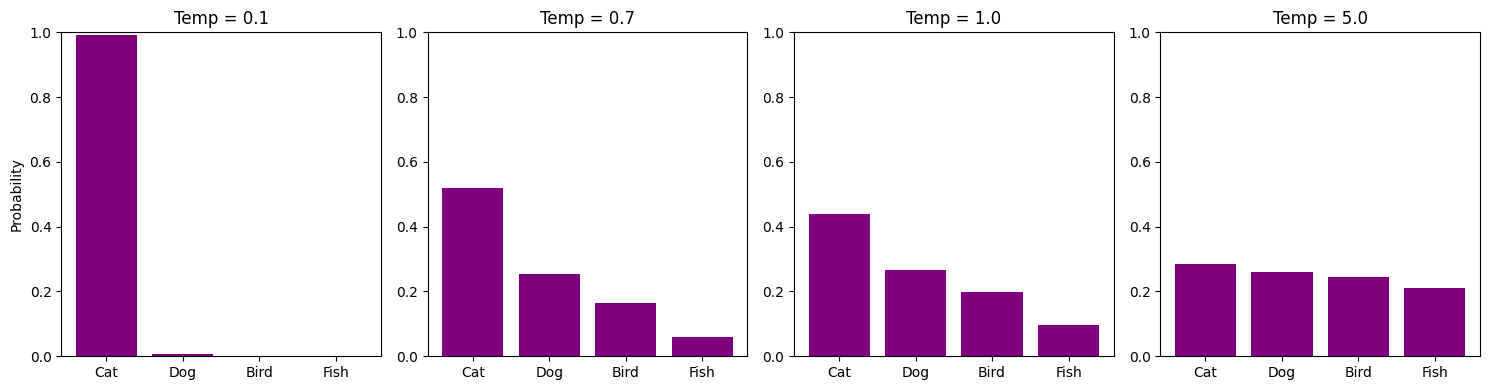

In [ ]:
# how changing T reshapes our model's confidence

def softmax_temp(logits, T):
  z = logits / T # Apply temperature scaling
  exp_z = np.exp(z - np.max(z)) # Numerical stability trick
  return exp_z / exp_z.sum()

logits = np.array([2.0, 1.5, 1.2, 0.5]) # "Cat", "Dog", "Bird", "Fish"
temps = [0.1, 0.7, 1.0, 5.0]

plt.figure(figsize=(15, 4))
x_labels = ["Cat", "Dog", "Bird", "Fish"]

for i, T in enumerate(temps):
  plt.subplot(1, 4, i+1)
  probs = softmax_temp(logits, T)
  plt.bar(x_labels, probs, color='purple')
  plt.title(f"Temp = {T}")
  plt.ylim(0, 1)
  if i == 0: plt.ylabel("Probability")

plt.tight_layout()
plt.show()

From the plot above, we can see that when $T = 0.1$, the model is sure it is a cat even though the raw logit for dog wasn't that much lower. At $T = 5$, the model is confused. It sees almost no difference between a Cat and a Fish.

As an AI researcher, we need to be aware of a major critique of Softmax which is that it is not a calibrated measure of uncertainty. Softmax can give a high probability to a class even if the inputs is completely different from the training data (Out-of-Distribution). It only knows how to compare the classes it has, not how to say *"I don't know".*

## Activation Wrap-UP

We have officially trekked from the primitive *"Yes/No"* toggle of the 1950s to the multi-path gated powerhouses driving LLM revolution today. If these functions were characters in a movie, the step function would be the grumpy grandfather who only gives one word answers, while SwiGLU would be the smooth talking high frequency trader managing ten screens at once.

Here is the cheatsheet you can follow:
- Need Speed? Use ReLU. It is the old reliable of the deep learning world.
- Building a Transformer? Stich with GELU (or SwiGLU if GPU budget)
- Outputs looking shaky? Check Softmax Temperature, might be running too hot.
- Vanishing Gradients? Stop using Sigmoid in hidden layers. It is 2026, let it enjoy its retirement

In the end, all this complex math serves one purpose that is giving a machine the ability to be flexible. By picking the right activation function, we are essentially choosing the personality og AI, deciding how it reacts to stress (negative inputs) and how it celebrates success (positive gradients). *If anyone asks why your model isn't converging, just squint at your moniotr and say "I suspect the non-monotonicity of the SwiGLU gate is interacting poorly with our weight initialization." It works everytime*